<a href="https://colab.research.google.com/github/birolcabukusta/Tools/blob/main/PAE_Comparison_AF3_Chai1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PAE Comparison — AlphaFold3 & Chai-1

This notebook scans your uploaded prediction files and plots Predicted Aligned Error (PAE) heatmaps for all models from both tools side-by-side.

**Two ways to provide your files — choose one in Cell 2:**
- **Option A — Upload directly** from your computer (simplest, no Google account needed)
- **Option B — Google Drive** if your files are already there

**Files expected:**
| Tool | File pattern | Notes |
|------|-------------|-------|
| AlphaFold 3 | `*_confidences.json` | Contains `"pae"` key |
| Chai-1 | `pae.rank_*.npy` | Plain 2-D NumPy array, Å |

---

## Cell 1 — Install & import libraries
Run this once at the start of every session.

In [1]:
# numpy and matplotlib are pre-installed in Colab; nothing extra needed.
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Image as IPImage

# ── Colour map: green (low/confident) → cream → orange (high/uncertain) ──────
PAE_CMAP = LinearSegmentedColormap.from_list(
    "pae",
    ["#1D9E75", "#9FE1CB", "#FFFDF5", "#FAC775", "#D85A30"],
    N=256,
)
PAE_MAX = 30.0  # Å ceiling for colour scale

print("✓ Libraries ready.")

✓ Libraries ready.


---
## Cell 2 — Load your files

**Choose Option A or Option B. Run only one.**

In [6]:
# ════════════════════════════════════════════════════════════
# OPTION A — Upload files directly from your computer
# ════════════════════════════════════════════════════════════
# A file picker will appear. Select ALL your AF3 + Chai files
# at once (Ctrl/Cmd+click for multiple files).
# They will be saved into /content/uploads/

from google.colab import files

UPLOAD_DIR = Path("/content/uploads")
UPLOAD_DIR.mkdir(exist_ok=True)

print("A file picker will appear — select all your PAE files (AF3 JSON and/or Chai NPY).")
uploaded = files.upload()

for filename, data in uploaded.items():
    dest = UPLOAD_DIR / filename
    dest.write_bytes(data)
    print(f"  Saved: {dest}")

# Point both tools at the same directory — the scanner will sort them by extension
AF3_DIR  = UPLOAD_DIR
CHAI_DIR = UPLOAD_DIR

print(f"\n✓ {len(uploaded)} file(s) uploaded to {UPLOAD_DIR}")

A file picker will appear — select all your PAE files (AF3 JSON and/or Chai NPY).



✓ 0 file(s) uploaded to /content/uploads


In [8]:
UPLOAD_DIR = Path("/content/uploads")
AF3_DIR  = UPLOAD_DIR
CHAI_DIR = UPLOAD_DIR

In [ ]:
# ════════════════════════════════════════════════════════════
# OPTION B — Load from Google Drive
# ════════════════════════════════════════════════════════════
# 1. Run this cell — you'll be asked to authorise Drive access.
# 2. Edit the two paths below to point at your AF3 and Chai folders.

from google.colab import drive
drive.mount("/content/drive")

# ── Edit these paths ─────────────────────────────────────────
AF3_DIR  = Path("/content/drive/MyDrive/YOUR_AF3_FOLDER")   # <-- change me
CHAI_DIR = Path("/content/drive/MyDrive/YOUR_CHAI_FOLDER")  # <-- change me
# If both tools' files are in the same folder, set both to the same path.
# ─────────────────────────────────────────────────────────────

print(f"AF3  directory : {AF3_DIR}  (exists={AF3_DIR.exists()})")
print(f"Chai directory : {CHAI_DIR}  (exists={CHAI_DIR.exists()})")

---
## Cell 3 — Configuration

Set your chain lengths here if you want chain-boundary lines and iPAE scores.  
Leave as `[]` to skip.

In [3]:
# ── Edit these values ─────────────────────────────────────────────────────────

# Number of residues per chain, in order.
# Example for a 150-residue + 120-residue complex: [150, 120]
# Leave as [] to plot without chain boundaries.
CHAIN_LENGTHS = []   # <-- edit me, e.g. [150, 120]

# Output filenames (saved to /content/ and shown inline)
OUT_GRID = "/content/pae_comparison.png"   # per-model grid
OUT_MEAN = "/content/pae_mean.png"         # consensus mean

# ─────────────────────────────────────────────────────────────────────────────
print("Chain lengths:", CHAIN_LENGTHS if CHAIN_LENGTHS else "(none — no boundary lines)")

Chain lengths: (none — no boundary lines)


---
## Cell 4 — Scan files & load PAE matrices

In [9]:
# ── Loaders ───────────────────────────────────────────────────────────────────

def load_af3_json(path):
    """Load PAE from an AF3 *_confidences.json file."""
    with open(path) as fh:
        data = json.load(fh)
    if "pae" not in data:
        raise KeyError(f"No 'pae' key in {path.name}. Is this an AF3 confidences file?")
    return np.array(data["pae"], dtype=np.float32)


def load_chai_npy(path):
    """Load PAE from a Chai-1 pae.rank_N.npy file."""
    arr = np.load(path).astype(np.float32)
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]  # squeeze (1, N, N) → (N, N)
    if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:
        raise ValueError(f"Unexpected PAE shape {arr.shape} in {path.name}.")
    return arr


# ── Scanners ──────────────────────────────────────────────────────────────────

def find_af3_files(directory):
    directory = Path(directory)
    files = sorted(directory.glob("*_confidences.json"))
    if not files:
        # Fallback: any JSON containing a 'pae' key
        for p in sorted(directory.glob("*.json")):
            try:
                with open(p) as fh:
                    if "pae" in json.load(fh):
                        files.append(p)
            except Exception:
                pass
    return files


def find_chai_files(directory):
    directory = Path(directory)
    files = sorted(directory.glob("pae.rank_*.npy"))
    if not files:
        files = sorted(directory.glob("*.npy"))
    return files


# ── Scan & load ───────────────────────────────────────────────────────────────

tool_data = {}  # {"AF3": [(label, matrix), ...], "Chai-1": [...]}

# AF3
af3_files = find_af3_files(AF3_DIR)
if af3_files:
    models = []
    for p in af3_files:
        try:
            pae = load_af3_json(p)
            label = p.stem.replace("_confidences", "")
            models.append((label, pae))
            print(f"[AF3]    {p.name}  →  shape {pae.shape}")
        except Exception as e:
            print(f"[AF3]    SKIP {p.name}: {e}")
    tool_data["AF3"] = models
else:
    print(f"[AF3]    No *_confidences.json files found in {AF3_DIR}")

# Chai-1
chai_files = find_chai_files(CHAI_DIR)
if chai_files:
    models = []
    for p in chai_files:
        try:
            pae = load_chai_npy(p)
            label = p.stem
            models.append((label, pae))
            print(f"[Chai-1] {p.name}  →  shape {pae.shape}")
        except Exception as e:
            print(f"[Chai-1] SKIP {p.name}: {e}")
    tool_data["Chai-1"] = models
else:
    print(f"[Chai-1] No pae.rank_*.npy files found in {CHAI_DIR}")

if not any(v for v in tool_data.values()):
    raise RuntimeError("No PAE files loaded. Check your directories and file names.")

print(f"\n✓ Loaded: " + ", ".join(f"{t}: {len(v)} model(s)" for t, v in tool_data.items() if v))

[AF3]    fold_2024_11_20_16_16_1013_cleaved_562_vapb_full_data_0.json  →  shape (1966, 1966)
[AF3]    fold_2024_11_20_16_16_1013_cleaved_562_vapb_full_data_1.json  →  shape (1966, 1966)
[AF3]    fold_2024_11_20_16_16_1013_cleaved_562_vapb_full_data_2.json  →  shape (1966, 1966)
[AF3]    fold_2024_11_20_16_16_1013_cleaved_562_vapb_full_data_3.json  →  shape (1966, 1966)
[AF3]    fold_2024_11_20_16_16_1013_cleaved_562_vapb_full_data_4.json  →  shape (1966, 1966)
[Chai-1] pae.rank_0.npy  →  shape (1723, 1723)
[Chai-1] pae.rank_1.npy  →  shape (1723, 1723)
[Chai-1] pae.rank_2.npy  →  shape (1723, 1723)
[Chai-1] pae.rank_3.npy  →  shape (1723, 1723)
[Chai-1] pae.rank_4.npy  →  shape (1723, 1723)

✓ Loaded: AF3: 5 model(s), Chai-1: 5 model(s)


---
## Cell 5 — Plot: per-model PAE grid

/tmp/ipykernel_24114/3886658104.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.08, 0, 0.91, 1.0])


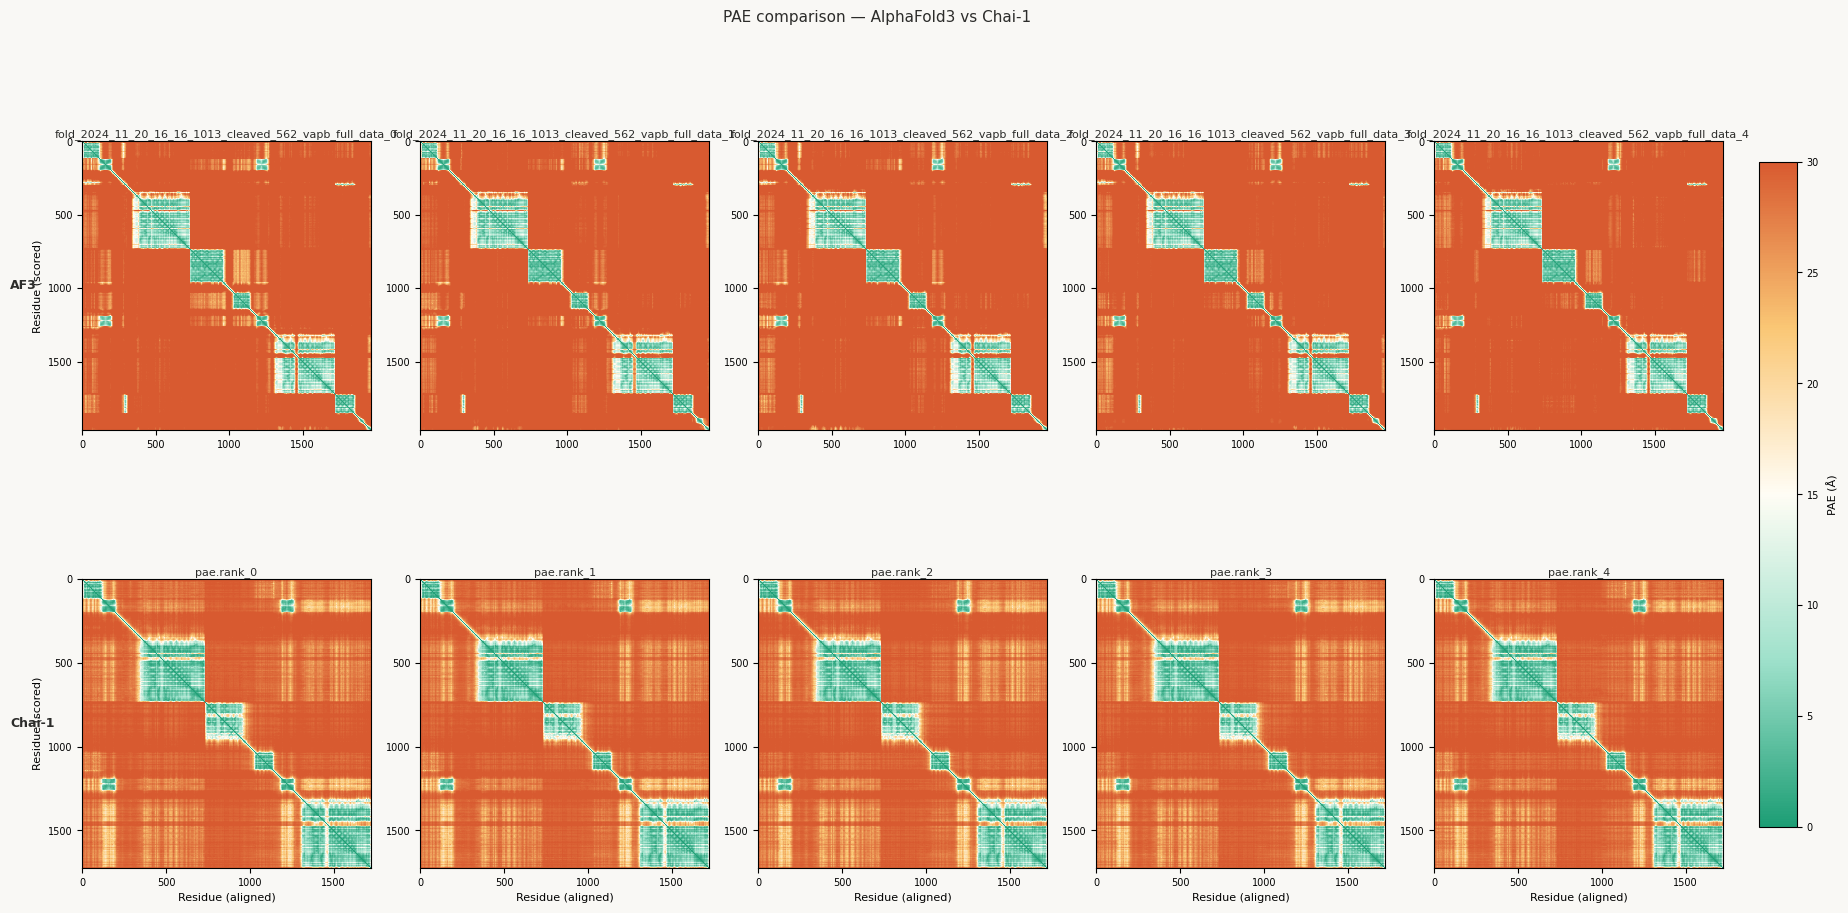

Saved → /content/pae_comparison.png


In [10]:
def draw_chain_lines(ax, chain_lengths):
    """Draw white dashed lines at chain boundaries."""
    cumulative = 0
    for length in chain_lengths[:-1]:
        cumulative += length
        b = cumulative - 0.5
        ax.axvline(b, color="white", linewidth=1.0, linestyle="--", alpha=0.8)
        ax.axhline(b, color="white", linewidth=1.0, linestyle="--", alpha=0.8)


def plot_pae_grid(tool_data, chain_lengths, out_path):
    tools   = [t for t in tool_data if tool_data.get(t)]
    n_rows  = len(tools)
    n_cols  = max(len(tool_data[t]) for t in tools)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(max(4 * n_cols + 1, 6), max(4 * n_rows + 1.5, 5)),
        squeeze=False,
    )
    fig.patch.set_facecolor("#F9F8F5")
    im_ref = None

    for row_idx, tool in enumerate(tools):
        for col_idx in range(n_cols):
            ax = axes[row_idx][col_idx]
            if col_idx < len(tool_data[tool]):
                label, pae = tool_data[tool][col_idx]
                im = ax.imshow(pae, cmap=PAE_CMAP, vmin=0, vmax=PAE_MAX,
                               aspect="equal", interpolation="nearest", origin="upper")
                im_ref = im
                if chain_lengths:
                    draw_chain_lines(ax, chain_lengths)
                ax.set_title(label, fontsize=8, pad=3, color="#2C2C2A")
                if col_idx == 0:
                    ax.set_ylabel("Residue (scored)", fontsize=8)
                if row_idx == n_rows - 1:
                    ax.set_xlabel("Residue (aligned)", fontsize=8)
                ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=4))
                ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=4))
                ax.tick_params(labelsize=7)
                # iPAE annotation
                if chain_lengths and len(chain_lengths) >= 2:
                    n_a = chain_lengths[0]
                    ipae = float(np.mean(pae[:n_a, n_a:]))
                    ax.text(0.98, 0.02, f"iPAE={ipae:.1f}Å",
                            transform=ax.transAxes, fontsize=7,
                            ha="right", va="bottom", color="white",
                            bbox=dict(boxstyle="round,pad=0.2",
                                      facecolor="#2C2C2A", alpha=0.65, edgecolor="none"))
            else:
                ax.set_visible(False)

        # Row label
        axes[row_idx][0].annotate(
            tool, xy=(0, 0.5), xycoords="axes fraction",
            xytext=(-52, 0), textcoords="offset points",
            fontsize=9, fontweight="bold", color="#2C2C2A",
            va="center", ha="left", annotation_clip=False,
        )

    if im_ref:
        cbar_ax = fig.add_axes([0.92, 0.15, 0.018, 0.70])
        cbar = fig.colorbar(im_ref, cax=cbar_ax)
        cbar.set_label("PAE (Å)", fontsize=8, labelpad=6)
        cbar.ax.tick_params(labelsize=7)

    fig.suptitle("PAE comparison — AlphaFold3 vs Chai-1",
                 fontsize=11, y=1.01, color="#2C2C2A")
    plt.tight_layout(rect=[0.08, 0, 0.91, 1.0])
    fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")
    plt.close(fig)


plot_pae_grid(tool_data, CHAIN_LENGTHS or None, OUT_GRID)

---
## Cell 6 — Plot: consensus mean PAE per tool

/tmp/ipykernel_24114/3087409681.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1.0])


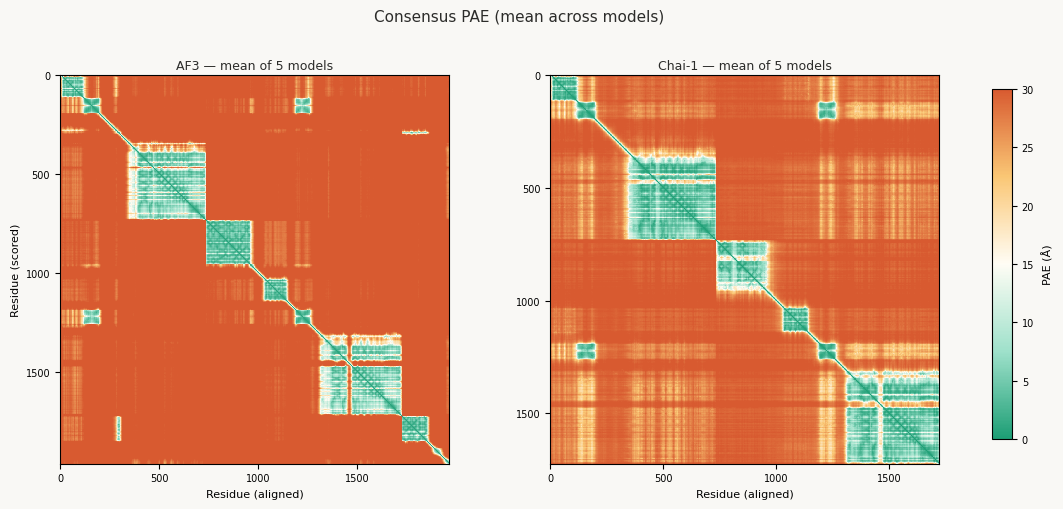

Saved → /content/pae_mean.png


In [11]:
def plot_mean_pae(tool_data, chain_lengths, out_path):
    tools = [t for t in tool_data if tool_data.get(t)]
    n     = len(tools)

    fig, axes = plt.subplots(1, n, figsize=(5 * n + 1, 5), squeeze=False)
    fig.patch.set_facecolor("#F9F8F5")
    im_ref = None

    for col, tool in enumerate(tools):
        matrices = [m for _, m in tool_data[tool]]
        min_size = min(m.shape[0] for m in matrices)
        stack    = np.stack([m[:min_size, :min_size] for m in matrices], axis=0)
        mean_pae = stack.mean(axis=0)

        ax = axes[0][col]
        im = ax.imshow(mean_pae, cmap=PAE_CMAP, vmin=0, vmax=PAE_MAX,
                       aspect="equal", interpolation="nearest", origin="upper")
        im_ref = im
        if chain_lengths:
            draw_chain_lines(ax, chain_lengths)

        ax.set_title(f"{tool} — mean of {len(matrices)} models",
                     fontsize=9, pad=4, color="#2C2C2A")
        ax.set_xlabel("Residue (aligned)", fontsize=8)
        if col == 0:
            ax.set_ylabel("Residue (scored)", fontsize=8)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=4))
        ax.tick_params(labelsize=7)

        if chain_lengths and len(chain_lengths) >= 2:
            n_a  = chain_lengths[0]
            ipae = float(np.mean(mean_pae[:n_a, n_a:]))
            ax.text(0.98, 0.02, f"mean iPAE={ipae:.1f}Å",
                    transform=ax.transAxes, fontsize=7,
                    ha="right", va="bottom", color="white",
                    bbox=dict(boxstyle="round,pad=0.2",
                              facecolor="#2C2C2A", alpha=0.65, edgecolor="none"))

    if im_ref:
        cbar_ax = fig.add_axes([0.93, 0.15, 0.018, 0.70])
        cbar = fig.colorbar(im_ref, cax=cbar_ax)
        cbar.set_label("PAE (Å)", fontsize=8, labelpad=6)
        cbar.ax.tick_params(labelsize=7)

    fig.suptitle("Consensus PAE (mean across models)",
                 fontsize=11, y=1.01, color="#2C2C2A")
    plt.tight_layout(rect=[0, 0, 0.92, 1.0])
    fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")
    plt.close(fig)


plot_mean_pae(tool_data, CHAIN_LENGTHS or None, OUT_MEAN)

---
## Cell 7 — iPAE summary table
Only meaningful if you set `CHAIN_LENGTHS` above.

In [ ]:
if CHAIN_LENGTHS and len(CHAIN_LENGTHS) >= 2:
    n_a = CHAIN_LENGTHS[0]
    print(f"{'Tool':<10} {'Model':<35} {'iPAE (Å)':>10}")
    print("-" * 57)
    for tool, models in tool_data.items():
        for label, pae in models:
            ipae = float(np.mean(pae[:n_a, n_a:]))
            flag = "  ✓" if ipae < 8 else ("  ~" if ipae < 15 else "  ✗")
            print(f"{tool:<10} {label:<35} {ipae:>10.2f}{flag}")
    print("\n  ✓ < 8 Å  →  confident interface")
    print("  ~  8–15 Å →  ambiguous")
    print("  ✗ > 15 Å  →  poorly constrained interface")
else:
    print("Set CHAIN_LENGTHS in Cell 3 to see iPAE scores.")

---
## Cell 8 — Download output files

In [ ]:
from google.colab import files

for path in [OUT_GRID, OUT_MEAN]:
    if os.path.exists(path):
        files.download(path)
        print(f"Downloading {path}")
    else:
        print(f"Not found: {path}")